<a href="https://colab.research.google.com/github/devwoo41/Experiments/blob/master/CoT_Prompting/last_letter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Last Letter Concatenation — Qwen2.5-7B 정밀 분석 (self-contained)

이 노트북은 **메인 실험 결과 없이도 단독으로 작동**합니다. vLLM 7B를 즉석 로드해 last_letter 300문제만 추론하고, 그 raw 응답을 메모리상 DataFrame으로 들고 있으면서 분석 결과를 결과창에 표/그래프로 띄웁니다.

### 소요 시간 (A100 40GB 기준)
- vLLM 설치: ~2분 (이미 설치돼있으면 skip)
- 7B 로드: ~3분
- 300문제 × (Standard + CoT) 추론: ~5~10분
- **총 약 10~15분**

### 분석 내용
1. Standard vs CoT 정확도 + 케이스 cross-tab
2. CoT만 정답인 케이스 raw 응답 비교 (CoT의 진짜 기여)
3. 오류 유형 자동 분류 (글자 수 부족 / 순서 / 추출 실패 등)
4. CoT reasoning chain 내부 step 정확도 (글자 추출 능력 vs 이어붙이기 능력 분리)
5. 입력 단어 특성과 정확도 상관


## 1. 환경 설정 (vLLM 설치 + V1 우회 패치)

vLLM 0.7+의 V1 엔진은 Jupyter `ipykernel` stdout과 호환성 문제(`io.UnsupportedOperation: fileno`)가 있으므로 V0 엔진 강제 + stdout monkey-patch 적용. **vLLM import 전에** 환경변수가 설정돼야 합니다.


In [1]:
!pip install -q vllm 2>&1 | tail -3

pylibraft-cu12 26.2.0 requires cuda-python<13.0,>=12.9.2, but you have cuda-python 13.2.0 which is incompatible.
google-adk 1.29.0 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.41.1 which is incompatible.
google-adk 1.29.0 requires opentelemetry-sdk<1.39.0,>=1.36.0, but you have opentelemetry-sdk 1.41.1 which is incompatible.


In [2]:
import os, sys, io

# (1) V1 엔진 비활성화 — vllm import 전 설정
os.environ["VLLM_USE_V1"] = "0"
os.environ["VLLM_WORKER_MULTIPROC_METHOD"] = "spawn"

# (2) ipykernel OutStream의 fileno() 미지원 우회
class _RealFilenoStream(io.IOBase):
    def __init__(self, original_stream, real_fd):
        self._original = original_stream
        self._real_fd = real_fd
    def __getattr__(self, name): return getattr(self._original, name)
    def fileno(self): return self._real_fd
    def write(self, s): return self._original.write(s)
    def flush(self): return self._original.flush()
    def writable(self): return True
    def readable(self): return False
    def isatty(self):   return False

if not getattr(sys.stdout, "_real_fileno_patched", False):
    sys.stdout = _RealFilenoStream(sys.stdout, 1)
    sys.stdout._real_fileno_patched = True
if not getattr(sys.stderr, "_real_fileno_patched", False):
    sys.stderr = _RealFilenoStream(sys.stderr, 2)
    sys.stderr._real_fileno_patched = True

if "vllm" in sys.modules:
    print("⚠ vllm이 이미 import됨. V1 비활성화가 적용 안 됐을 수 있음 → 런타임 재시작 후 다시 실행하세요.")
else:
    print("✓ V1 비활성화 + stdout patch 적용")

✓ V1 비활성화 + stdout patch 적용


## 2. Last Letter 데이터 300문제 생성 (in-memory)

논문 §3.3의 in-domain 설정(4단어) 그대로. 영어 이름 풀에서 4개 샘플 → 각 단어의 마지막 글자를 이어 붙임. seed=42로 재현 가능.


In [3]:
import random, re, json
from dataclasses import dataclass
from collections import Counter
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 200)

SEED = 42
N_PROBLEMS = 300

_NAMES = [
    "James","Mary","John","Patricia","Robert","Jennifer","Michael","Linda",
    "William","Elizabeth","David","Barbara","Richard","Susan","Joseph","Jessica",
    "Thomas","Sarah","Charles","Karen","Christopher","Nancy","Daniel","Lisa",
    "Matthew","Margaret","Anthony","Betty","Mark","Sandra","Donald","Ashley",
    "Steven","Kimberly","Paul","Emily","Andrew","Donna","Joshua","Michelle",
    "Kenneth","Carol","Kevin","Amanda","Brian","Melissa","George","Deborah",
    "Edward","Stephanie","Ronald","Dorothy","Timothy","Rebecca","Jason","Sharon",
    "Jeffrey","Laura","Ryan","Cynthia","Jacob","Amy","Gary","Kathleen",
]

def generate_problems(n, seed):
    rng = random.Random(seed)
    out = []
    for i in range(n):
        names = rng.sample(_NAMES, 4)
        q = f'Take the last letters of the words in "{" ".join(names)}" and concatenate them.'
        ans = "".join(name[-1].lower() for name in names)
        out.append({"idx": i, "question": q, "gold": ans, "words": names})
    return out

problems = generate_problems(N_PROBLEMS, SEED)
print(f"{len(problems)}문제 생성. 첫 3개 sample:")
for p in problems[:3]:
    print(f"  Q: {p['question'][:80]}...  →  A: {p['gold']}")

300문제 생성. 첫 3개 sample:
  Q: Take the last letters of the words in "Joseph Patricia Emily Ashley" and concate...  →  A: hayy
  Q: Take the last letters of the words in "Mark Sarah Susan Barbara" and concatenate...  →  A: khna
  Q: Take the last letters of the words in "Jason Robert Patricia Barbara" and concat...  →  A: ntaa


## 3. 프롬프트 — 논문 Appendix G Table 21 (4-shot)

논문의 in-context exemplar를 그대로 옮김. CoT 조건은 reasoning chain 포함, Standard 조건은 최종 답만.


In [4]:
_EXEMPLARS = [
    ('Take the last letters of the words in "Elon Musk" and concatenate them.',
     'The last letter of "Elon" is "n". The last letter of "Musk" is "k". '
     'Concatenating them is "nk". The answer is nk.',
     "nk"),
    ('Take the last letters of the words in "Larry Page" and concatenate them.',
     'The last letter of "Larry" is "y". The last letter of "Page" is "e". '
     'Concatenating them is "ye". The answer is ye.',
     "ye"),
    ('Take the last letters of the words in "Sergey Brin" and concatenate them.',
     'The last letter of "Sergey" is "y". The last letter of "Brin" is "n". '
     'Concatenating them is "yn". The answer is yn.',
     "yn"),
    ('Take the last letters of the words in "Bill Gates" and concatenate them.',
     'The last letter of "Bill" is "l". The last letter of "Gates" is "s". '
     'Concatenating them is "ls". The answer is ls.',
     "ls"),
]

def build_prompt(question: str, condition: str) -> str:
    parts = []
    for q, rat, fin in _EXEMPLARS:
        ans_text = rat if condition == "cot" else f"The answer is {fin}."
        parts.append(f"Q: {q}\nA: {ans_text}")
    parts.append(f"Q: {question}\nA:")
    return "\n\n".join(parts)

print("=== CoT 프롬프트 (마지막 exemplar만 표시) ===")
print(build_prompt(problems[0]["question"], "cot").split("\n\n")[-2])
print("\n=== Standard 프롬프트 (마지막 exemplar만 표시) ===")
print(build_prompt(problems[0]["question"], "standard").split("\n\n")[-2])

=== CoT 프롬프트 (마지막 exemplar만 표시) ===
Q: Take the last letters of the words in "Bill Gates" and concatenate them.
A: The last letter of "Bill" is "l". The last letter of "Gates" is "s". Concatenating them is "ls". The answer is ls.

=== Standard 프롬프트 (마지막 exemplar만 표시) ===
Q: Take the last letters of the words in "Bill Gates" and concatenate them.
A: The answer is ls.


## 4. Qwen2.5-7B 로드 후 두 조건 추론

A100 40GB에서 fp16 적재 (~14GB). max_model_len=4096이면 8-shot 프롬프트 + 응답 충분.

⏱ 이 셀이 가장 오래 걸립니다 (로드 ~3분 + 추론 ~5-10분).


In [5]:
from vllm import LLM, SamplingParams
import gc

MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"

llm = LLM(
    model=MODEL_ID,
    dtype="float16",
    max_model_len=4096,
    gpu_memory_utilization=0.90,
    trust_remote_code=True,
)
tok = llm.get_tokenizer()

def _chat(p):
    return tok.apply_chat_template(
        [{"role": "user", "content": p}],
        tokenize=False, add_generation_prompt=True,
    )

# Standard 추론 (greedy)
std_prompts = [_chat(build_prompt(p["question"], "standard")) for p in problems]
sp_greedy = SamplingParams(temperature=0.0, max_tokens=512)
std_outs = llm.generate(std_prompts, sp_greedy, use_tqdm=True)
std_raw = [o.outputs[0].text for o in std_outs]

# CoT 추론 (greedy)
cot_prompts = [_chat(build_prompt(p["question"], "cot")) for p in problems]
cot_outs = llm.generate(cot_prompts, sp_greedy, use_tqdm=True)
cot_raw = [o.outputs[0].text for o in cot_outs]

# 메모리 해제
del llm
gc.collect()
try:
    import torch; torch.cuda.empty_cache()
except Exception:
    pass

print(f"\n추론 완료. std_raw {len(std_raw)}개, cot_raw {len(cot_raw)}개")

INFO 05-14 05:15:52 [utils.py:233] non-default args: {'trust_remote_code': True, 'dtype': 'float16', 'max_model_len': 4096, 'gpu_memory_utilization': 0.9, 'disable_log_stats': True, 'model': 'Qwen/Qwen2.5-7B-Instruct'}
WARNING 05-14 05:15:52 [envs.py:1830] Unknown vLLM environment variable detected: VLLM_USE_V1


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

INFO 05-14 05:16:22 [nixl_utils.py:20] Setting UCX_RCACHE_MAX_UNRELEASED to '1024' to avoid a rare memory leak in UCX when using NIXL.
WARNING 05-14 05:16:22 [nixl_utils.py:34] NIXL is not available
WARNING 05-14 05:16:22 [nixl_utils.py:44] NIXL agent config is not available
INFO 05-14 05:16:22 [model.py:555] Resolved architecture: Qwen2ForCausalLM
WARNING 05-14 05:16:22 [model.py:2018] Casting torch.bfloat16 to torch.float16.
INFO 05-14 05:16:22 [model.py:1680] Using max model len 4096
INFO 05-14 05:16:22 [scheduler.py:239] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 05-14 05:16:22 [vllm.py:840] Asynchronous scheduling is enabled.
INFO 05-14 05:16:22 [kernel.py:205] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'])


tokenizer_config.json: 0.00B [00:00, ?B/s]

...

Rendering prompts:   0%|          | 0/300 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/300 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Rendering prompts:   0%|          | 0/300 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/300 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]


추론 완료. std_raw 300개, cot_raw 300개


## 5. 답 추출 (regex) + 정답 여부 라벨링

논문 방식: `The answer is X` 패턴을 1순위, 실패 시 인용부호로 감싸인 알파벳 토큰을 fallback. `pred`와 `gold`를 비교해 `correct` 플래그.


In [6]:
_ANSWER_IS_RE = re.compile(r"[Tt]he answer is\s*:?\s*(.+?)(?:[\.\n]|$)", re.DOTALL)

def extract_last_letter(text: str):
    m = _ANSWER_IS_RE.search(text)
    if m:
        tail = m.group(1).strip().strip('"').strip("'").strip(".")
        only_alpha = re.sub(r"[^a-zA-Z]", "", tail)
        if only_alpha:
            return only_alpha.lower(), "primary"
    quoted = re.findall(r'"([a-zA-Z]+)"', text)
    if quoted:
        return quoted[-1].lower(), "fallback_quoted"
    return "", "failed"

def normalize(s):
    return (s or "").strip().lower()

def build_df(problems_, raw_):
    rows = []
    for p, r in zip(problems_, raw_):
        val, method = extract_last_letter(r)
        rows.append({
            "idx": p["idx"],
            "question": p["question"],
            "gold": p["gold"],
            "words": p["words"],
            "pred": val,
            "method": method,
            "raw": r,
        })
    df = pd.DataFrame(rows)
    df["correct"] = df.apply(lambda r: normalize(r["pred"]) == normalize(r["gold"]), axis=1)
    return df

std = build_df(problems, std_raw)
cot = build_df(problems, cot_raw)

print(f"Standard: {std['correct'].sum():3d}/{len(std)} ({std['correct'].mean()*100:5.2f}%) 정답")
print(f"CoT     : {cot['correct'].sum():3d}/{len(cot)} ({cot['correct'].mean()*100:5.2f}%) 정답")
print(f"\n추출 실패율 - Standard: {(std['method']=='failed').mean()*100:.1f}%, "
      f"CoT: {(cot['method']=='failed').mean()*100:.1f}%")

Standard:   0/300 ( 0.00%) 정답
CoT     :  71/300 (23.67%) 정답

추출 실패율 - Standard: 0.0%, CoT: 0.0%


## 6. 케이스 cross-tab

같은 문제에 대해 두 조건의 정답 여부를 교차표로:
- **양쪽 정답** / **양쪽 오답** / **Standard만** / **CoT만 정답** ⭐


In [7]:
m = std.merge(cot, on="idx", suffixes=("_std", "_cot"))
m["gold"]     = m["gold_std"]
m["question"] = m["question_std"]

ct = pd.crosstab(m["correct_std"], m["correct_cot"],
                 rownames=["Standard 정답?"], colnames=["CoT 정답?"])
print("=== 케이스 분포 ===")
display(ct)

both_right = m[ m.correct_std &  m.correct_cot]
both_wrong = m[~m.correct_std & ~m.correct_cot]
std_only   = m[ m.correct_std & ~m.correct_cot]
cot_only   = m[~m.correct_std &  m.correct_cot]

print(f"\n양쪽 정답   : {len(both_right):3d}")
print(f"Standard만  : {len(std_only):3d}  (CoT가 망친 경우)")
print(f"CoT만 정답  : {len(cot_only):3d}  ⭐ CoT의 진짜 기여")
print(f"양쪽 오답   : {len(both_wrong):3d}  (7B로는 못 푸는 문제)")

=== 케이스 분포 ===


CoT 정답?,False,True
Standard 정답?,,
False,229,71



양쪽 정답   :   0
Standard만  :   0  (CoT가 망친 경우)
CoT만 정답  :  71  ⭐ CoT의 진짜 기여
양쪽 오답   : 229  (7B로는 못 푸는 문제)


## 7. ⭐ CoT만 정답인 케이스 — raw 응답 비교

CoT가 어떻게 답에 도달했는지 직접 봅니다.


In [8]:
def _trim(s, n=300):
    s = (s or "").replace("\n", " ⏎ ").strip()
    return s if len(s) <= n else s[:n] + " ...[truncated]"

view = cot_only[["question", "gold", "pred_std", "pred_cot"]].copy()
view["raw_std_short"] = cot_only["raw_std"].apply(_trim)
view["raw_cot_short"] = cot_only["raw_cot"].apply(_trim)
display(view.head(10))

,question,gold,pred_std,pred_cot,raw_std_short,raw_cot_short
3,"Take the last letters of the words in ""Betty Sandra Patricia Margaret"" and concatenate them.",yaat,rtpm,yaat,The answer is rtpm.,"The last letter of ""Betty"" is ""y"". The last letter of ""Sandra"" is ""a"". The last letter of ""Patricia"" is ""a"". The last letter of ""Margaret"" is ""t"". Concatenating them is ""yaat"". The answer is yaat."
4,"Take the last letters of the words in ""Rebecca Mark Laura Emily"" and concatenate them.",akay,arae,akay,The answer is arae.,"The last letter of ""Rebecca"" is ""a"". The last letter of ""Mark"" is ""k"". The last letter of ""Laura"" is ""a"". The last letter of ""Emily"" is ""y"". Concatenating them is ""akay"". The answer is akay."
6,"Take the last letters of the words in ""Emily Karen Betty Amanda"" and concatenate them.",ynya,ynbma,ynya,The answer is ynbma.,"The last letter of ""Emily"" is ""y"". The last letter of ""Karen"" is ""n"". The last letter of ""Betty"" is ""y"". The last letter of ""Amanda"" is ""a"". Concatenating them is ""ynya"". The answer is ynya."
18,"Take the last letters of the words in ""Dorothy Paul William Betty"" and concatenate them.",ylmy,ywbe,ylmy,The answer is ywbe.,"The last letter of ""Dorothy"" is ""y"". The last letter of ""Paul"" is ""l"". The last letter of ""William"" is ""m"". The last letter of ""Betty"" is ""y"". Concatenating them is ""ylmy"". The answer is ylmy."
24,"Take the last letters of the words in ""Christopher Jason William Stephanie"" and concatenate them.",rnme,anws,rnme,The answer is anws.,"The last letter of ""Christopher"" is ""r"". The last letter of ""Jason"" is ""n"". The last letter of ""William"" is ""m"". The last letter of ""Stephanie"" is ""e"". Concatenating them is ""rnme"". The answer is ..."
25,"Take the last letters of the words in ""Edward Cynthia Steven Mary"" and concatenate them.",dany,nystrom,dany,The answer is nystrom.,"The last letter of ""Edward"" is ""d"". The last letter of ""Cynthia"" is ""a"". The last letter of ""Steven"" is ""n"". The last letter of ""Mary"" is ""y"". Concatenating them is ""dany"". The answer is dany."
28,"Take the last letters of the words in ""Kimberly Daniel Susan Joshua"" and concatenate them.",ylna,yas,ylna,The answer is yas.,"The last letter of ""Kimberly"" is ""y"". The last letter of ""Daniel"" is ""l"". The last letter of ""Susan"" is ""n"". The last letter of ""Joshua"" is ""a"". Concatenating them is ""ylna"". The answer is ylna."
30,"Take the last letters of the words in ""James Carol Gary John"" and concatenate them.",slyn,olry,slyn,The answer is olry.,"The last letter of ""James"" is ""s"". The last letter of ""Carol"" is ""l"". The last letter of ""Gary"" is ""y"". The last letter of ""John"" is ""n"". Concatenating them is ""slyn"". The answer is slyn."
34,"Take the last letters of the words in ""Kimberly Jason Betty Margaret"" and concatenate them.",ynyt,ytbm,ynyt,The answer is ytbm.,"The last letter of ""Kimberly"" is ""y"". The last letter of ""Jason"" is ""n"". The last letter of ""Betty"" is ""y"". The last letter of ""Margaret"" is ""t"". Concatenating them is ""ynyt"". The answer is ynyt."
36,"Take the last letters of the words in ""Laura Jessica Ashley Mark"" and concatenate them.",aayk,ckm,aayk,The answer is ckm.,"The last letter of ""Laura"" is ""a"". The last letter of ""Jessica"" is ""a"". The last letter of ""Ashley"" is ""y"". The last letter of ""Mark"" is ""k"". Concatenating them is ""aayk"". The answer is aayk."


## 8. 양쪽 오답 케이스 (7B의 한계)

CoT로도 못 푼 문제는 무엇이 모델을 헷갈리게 했는지.


In [9]:
view2 = both_wrong[["question", "gold", "pred_std", "pred_cot"]].copy()
view2["raw_cot_short"] = both_wrong["raw_cot"].apply(lambda r: _trim(r, 350))
display(view2.head(8))

,question,gold,pred_std,pred_cot,raw_cot_short
0,"Take the last letters of the words in ""Joseph Patricia Emily Ashley"" and concatenate them.",hayy,ya,saya,"The last letter of ""Joseph"" is ""s"". The last letter of ""Patricia"" is ""a"". The last letter of ""Emily"" is ""y"". The last letter of ""Ashley"" is ""y"". Concatenating them is ""saya"". The answer is saya."
1,"Take the last letters of the words in ""Mark Sarah Susan Barbara"" and concatenate them.",khna,rahusb,khan,"The last letter of ""Mark"" is ""k"". The last letter of ""Sarah"" is ""h"". The last letter of ""Susan"" is ""n"". The last letter of ""Barbara"" is ""a"". Concatenating them is ""khan"". The answer is khan."
2,"Take the last letters of the words in ""Jason Robert Patricia Barbara"" and concatenate them.",ntaa,arbp,ntapaa,"The last letter of ""Jason"" is ""n"". The last letter of ""Robert"" is ""t"". The last letter of ""Patricia"" is ""a"". The last letter of ""Barbara"" is ""a"". Concatenating them is ""ntapa"". The answer is ntapaa."
5,"Take the last letters of the words in ""James Christopher Jason Amanda"" and concatenate them.",srna,ona,ssn,"The last letter of ""James"" is ""s"". The last letter of ""Christopher"" is ""s"". The last letter of ""Jason"" is ""n"". The last letter of ""Amanda"" is ""a"". Concatenating them is ""ssn"". The answer is ssn."
7,"Take the last letters of the words in ""Susan Barbara Edward Richard"" and concatenate them.",nadd,ardr,nadh,"The last letter of ""Susan"" is ""n"". The last letter of ""Barbara"" is ""a"". The last letter of ""Edward"" is ""d"". The last letter of ""Richard"" is ""h"". Concatenating them is ""nadh"". The answer is nadh."
8,"Take the last letters of the words in ""Melissa Brian Kimberly Jennifer"" and concatenate them.",anyr,anbkj,any,"The last letter of ""Melissa"" is ""a"". The last letter of ""Brian"" is ""n"". The last letter of ""Kimberly"" is ""y"". The last letter of ""Jennifer"" is ""n"". Concatenating them is ""any"". The answer is any."
9,"Take the last letters of the words in ""Ryan Jessica Edward David"" and concatenate them.",nadd,yjed,nadb,"The last letter of ""Ryan"" is ""n"". The last letter of ""Jessica"" is ""a"". The last letter of ""Edward"" is ""d"". The last letter of ""David"" is ""d"". Concatenating them is ""nadb"". The answer is nadb."
10,"Take the last letters of the words in ""Donna George Matthew William"" and concatenate them.",aewm,egew,aehm,"The last letter of ""Donna"" is ""a"". The last letter of ""George"" is ""e"". The last letter of ""Matthew"" is ""h"". The last letter of ""William"" is ""m"". Concatenating them is ""aehm"". The answer is aehm."


## 9. 오류 유형 자동 분류

- `correct`: 정답
- `extraction_failed`: 빈 답 (추출 실패)
- `length_short` / `length_long`: 글자 수 부족/초과
- `anagram`: 글자 구성은 동일하나 순서가 다름 (글자는 뽑았으나 concat 순서 실수)
- `partial_match`: 1글자 빼고 다 맞음
- `wrong_letters`: 글자 자체가 다름


In [10]:
def classify_error(pred, gold):
    p, g = normalize(pred), normalize(gold)
    if p == g: return "correct"
    if not p: return "extraction_failed"
    if len(p) != len(g):
        return "length_short" if len(p) < len(g) else "length_long"
    if sorted(p) == sorted(g): return "anagram"
    overlap = sum(1 for c in p if c in g)
    if overlap >= len(g) - 1: return "partial_match"
    return "wrong_letters"

std["err"] = std.apply(lambda r: classify_error(r["pred"], r["gold"]), axis=1)
cot["err"] = cot.apply(lambda r: classify_error(r["pred"], r["gold"]), axis=1)

err_order = ["correct", "anagram", "partial_match", "length_short",
             "length_long", "wrong_letters", "extraction_failed"]
err_dist = pd.DataFrame({
    "Standard": std["err"].value_counts(),
    "CoT":      cot["err"].value_counts(),
}).reindex(err_order).fillna(0).astype(int)
err_dist["Std %"] = (err_dist["Standard"] / len(std) * 100).round(1)
err_dist["CoT %"] = (err_dist["CoT"]      / len(cot) * 100).round(1)
print("=== 오류 유형 분포 ===")
display(err_dist)

=== 오류 유형 분포 ===


,Standard,CoT,Std %,CoT %
err,,,,
correct,0,71,0.0,23.7
anagram,0,18,0.0,6.0
partial_match,12,103,4.0,34.3
length_short,69,37,23.0,12.3
length_long,91,50,30.3,16.7
wrong_letters,128,21,42.7,7.0
extraction_failed,0,0,0.0,0.0


/tmp/ipykernel_4764/767306322.py:11: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4764/767306322.py:11: UserWarning: Glyph 47448 (\N{HANGUL SYLLABLE RYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4764/767306322.py:11: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4764/767306322.py:11: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4764/767306322.py:11: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4764/767306322.py:11: UserWarning: Glyph 54637 (\N{HANGUL SYLLABLE HANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4764/767306322.py:11: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

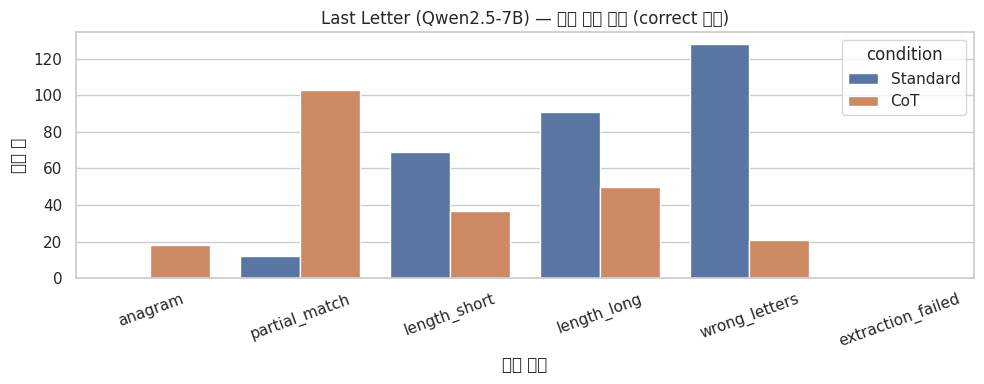

In [11]:
# 막대그래프
plot_df = err_dist[["Standard", "CoT"]].drop("correct", errors="ignore").reset_index()
plot_df = plot_df.rename(columns={"index": "err"})
melted = plot_df.melt(id_vars="err", var_name="condition", value_name="count")

plt.figure(figsize=(10, 4))
sns.barplot(data=melted, x="err", y="count", hue="condition")
plt.title("Last Letter (Qwen2.5-7B) — 오류 유형 분포 (correct 제외)")
plt.ylabel("문항 수"); plt.xlabel("오류 유형")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 10. ⭐ CoT reasoning chain 내부 step 분석

CoT 응답은 보통 단어별로 last letter를 명시:
```
The last letter of "James" is "s".
The last letter of "Robert" is "t".
Concatenating them is "st...". The answer is st....
```

여기서 두 가지를 분리:
- **Step 정확도**: 각 단어의 마지막 글자를 모델이 올바르게 추출하는가?
- **Concat 정확도**: step이 다 맞아도 마지막 연결에서 틀리는가? (working memory 한계 시그널)


In [12]:
STEP_RE = re.compile(
    r'''last\s+letter\s+of\s+["']?([A-Za-z]+)["']?\s+is\s+["']?([A-Za-z])["']?''',
    re.IGNORECASE,
)

def extract_steps(raw):
    return [(w, l) for w, l in STEP_RE.findall(raw or "")]

cot["steps"]        = cot["raw"].apply(extract_steps)
cot["n_steps_out"]  = cot["steps"].apply(len)

print("응답 step 추출 수 분포:", Counter(cot["n_steps_out"]))

응답 step 추출 수 분포: Counter({4: 299, 5: 1})


In [13]:
def step_accuracy(row):
    correct = sum(1 for w, l in row["steps"] if w[-1].lower() == l.lower())
    return correct, len(row["steps"])

cot[["step_correct", "step_total"]] = cot.apply(
    lambda r: pd.Series(step_accuracy(r)), axis=1
)
cot["all_steps_correct"] = (cot["step_correct"] == cot["step_total"]) & (cot["step_total"] > 0)

ts, cs = int(cot["step_total"].sum()), int(cot["step_correct"].sum())
print(f"전체 step accuracy: {cs}/{ts} = {cs/max(ts,1)*100:.1f}%")

m_all = cot[cot["all_steps_correct"]]
breakdown = pd.Series({
    "step 다 맞음 & 최종 정답"    : int((m_all["correct"]).sum()),
    "step 다 맞음 & 최종 오답"    : int((~m_all["correct"]).sum()),
    "step 일부 틀림 & 최종 정답"  : int((cot[~cot["all_steps_correct"] &  cot["correct"]]).shape[0]),
    "step 일부 틀림 & 최종 오답"  : int((cot[~cot["all_steps_correct"] & ~cot["correct"]]).shape[0]),
}, name="문항 수")
print("\n=== CoT 내부 step ↔ 최종 답 일치 분해 ===")
display(breakdown.to_frame())
print(
    "\n해석:\n"
    "  - 'step 다 맞음 & 최종 오답'이 크면 → 글자는 뽑지만 concat에서 실수 (working memory)\n"
    "  - 'step 일부 틀림 & 최종 정답'은 보통 매우 적음"
)

전체 step accuracy: 982/1201 = 81.8%

=== CoT 내부 step ↔ 최종 답 일치 분해 ===


,문항 수
step 다 맞음 & 최종 정답,71
step 다 맞음 & 최종 오답,61
step 일부 틀림 & 최종 정답,0
step 일부 틀림 & 최종 오답,168



해석:
  - 'step 다 맞음 & 최종 오답'이 크면 → 글자는 뽑지만 concat에서 실수 (working memory)
  - 'step 일부 틀림 & 최종 정답'은 보통 매우 적음


In [14]:
# 단어 position별 step 정확도
pos = []
for _, row in cot.iterrows():
    for i, (w, l) in enumerate(row["steps"][:4]):
        pos.append({"position": i, "correct": int(w[-1].lower() == l.lower())})
pos_df = pd.DataFrame(pos)
if len(pos_df):
    by_pos = pos_df.groupby("position")["correct"].agg(["mean", "count"])
    by_pos["accuracy %"] = (by_pos["mean"] * 100).round(1)
    by_pos = by_pos[["accuracy %", "count"]]
    print("=== 단어 position별 step 정확도 ===")
    display(by_pos)
    print("(position 0 = 첫 단어, position 3 = 마지막 단어)")

=== 단어 position별 step 정확도 ===


,accuracy %,count
position,,
0,84.0,300
1,83.0,300
2,80.3,300
3,79.7,300


(position 0 = 첫 단어, position 3 = 마지막 단어)


## 11. ⭐ "step 다 맞음 & 최종 오답" 케이스 직접 보기

이 카테고리가 클수록 7B의 한계는 **"글자는 안다 / 이어붙이기를 못 한다"** — working memory 부족.


In [15]:
tricky = cot[cot["all_steps_correct"] & ~cot["correct"]].copy()
print(f"카테고리 문항 수: {len(tricky)}")

if len(tricky):
    tv = tricky[["question", "gold", "pred", "steps"]].copy()
    tv["model_letters"] = tricky["steps"].apply(lambda s: "".join(l.lower() for _, l in s))
    tv["raw_short"] = tricky["raw"].apply(lambda r: _trim(r, 350))
    display(tv.head(10))
else:
    print("비어있음 → 7B에서 글자 추출과 concat 능력이 거의 동기화됨.")

카테고리 문항 수: 61


,question,gold,pred,steps,model_letters,raw_short
1,"Take the last letters of the words in ""Mark Sarah Susan Barbara"" and concatenate them.",khna,khan,"[(Mark, k), (Sarah, h), (Susan, n), (Barbara, a)]",khna,"The last letter of ""Mark"" is ""k"". The last letter of ""Sarah"" is ""h"". The last letter of ""Susan"" is ""n"". The last letter of ""Barbara"" is ""a"". Concatenating them is ""khan"". The answer is khan."
2,"Take the last letters of the words in ""Jason Robert Patricia Barbara"" and concatenate them.",ntaa,ntapaa,"[(Jason, n), (Robert, t), (Patricia, a), (Barbara, a)]",ntaa,"The last letter of ""Jason"" is ""n"". The last letter of ""Robert"" is ""t"". The last letter of ""Patricia"" is ""a"". The last letter of ""Barbara"" is ""a"". Concatenating them is ""ntapa"". The answer is ntapaa."
9,"Take the last letters of the words in ""Ryan Jessica Edward David"" and concatenate them.",nadd,nadb,"[(Ryan, n), (Jessica, a), (Edward, d), (David, d)]",nadd,"The last letter of ""Ryan"" is ""n"". The last letter of ""Jessica"" is ""a"". The last letter of ""Edward"" is ""d"". The last letter of ""David"" is ""d"". Concatenating them is ""nadb"". The answer is nadb."
12,"Take the last letters of the words in ""Sandra Richard Edward Emily"" and concatenate them.",addy,adddy,"[(Sandra, a), (Richard, d), (Edward, d), (Emily, y)]",addy,"The last letter of ""Sandra"" is ""a"". The last letter of ""Richard"" is ""d"". The last letter of ""Edward"" is ""d"". The last letter of ""Emily"" is ""y"". Concatenating them is ""adddy"". The answer is adddy."
15,"Take the last letters of the words in ""Nancy Ashley Christopher Cynthia"" and concatenate them.",yyra,yrha,"[(Nancy, y), (Ashley, y), (Christopher, r), (Cynthia, a)]",yyra,"The last letter of ""Nancy"" is ""y"". The last letter of ""Ashley"" is ""y"". The last letter of ""Christopher"" is ""r"". The last letter of ""Cynthia"" is ""a"". Concatenating them is ""yrha"". The answer is yrha."
16,"Take the last letters of the words in ""Edward Paul Mark Carol"" and concatenate them.",dlkl,dltk,"[(Edward, d), (Paul, l), (Mark, k), (Carol, l)]",dlkl,"The last letter of ""Edward"" is ""d"". The last letter of ""Paul"" is ""l"". The last letter of ""Mark"" is ""k"". The last letter of ""Carol"" is ""l"". Concatenating them is ""dltk"". The answer is dltk."
20,"Take the last letters of the words in ""Ryan Charles Kimberly Sarah"" and concatenate them.",nsyh,nshy,"[(Ryan, n), (Charles, s), (Kimberly, y), (Sarah, h)]",nsyh,"The last letter of ""Ryan"" is ""n"". The last letter of ""Charles"" is ""s"". The last letter of ""Kimberly"" is ""y"". The last letter of ""Sarah"" is ""h"". Concatenating them is ""nshy"". The answer is nshy."
21,"Take the last letters of the words in ""Ashley Kimberly Jason Dorothy"" and concatenate them.",yyny,ynyy,"[(Ashley, y), (Kimberly, y), (Jason, n), (Dorothy, y)]",yyny,"The last letter of ""Ashley"" is ""y"". The last letter of ""Kimberly"" is ""y"". The last letter of ""Jason"" is ""n"". The last letter of ""Dorothy"" is ""y"". Concatenating them is ""ynyy"". The answer is ynyy."
22,"Take the last letters of the words in ""George Mark Sarah Kathleen"" and concatenate them.",ekhn,ekhnn,"[(George, e), (Mark, k), (Sarah, h), (Kathleen, n)]",ekhn,"The last letter of ""George"" is ""e"". The last letter of ""Mark"" is ""k"". The last letter of ""Sarah"" is ""h"". The last letter of ""Kathleen"" is ""n"". Concatenating them is ""ekhnn"". The answer is ekhnn."
26,"Take the last letters of the words in ""Joseph Paul Amanda Donna"" and concatenate them.",hlaa,hlada,"[(Joseph, h), (Paul, l), (Amanda, a), (Donna, a)]",hlaa,"The last letter of ""Joseph"" is ""h"". The last letter of ""Paul"" is ""l"". The last letter of ""Amanda"" is ""a"". The last letter of ""Donna"" is ""a"". Concatenating them is ""hlada"". The answer is hlada."


## 12. 입력 변수 vs 정확도

단어 길이, 글자 등이 정확도에 영향을 주는지.


In [16]:
cot["avg_word_len"] = cot["words"].apply(lambda ws: float(np.mean([len(w) for w in ws])))
std["avg_word_len"] = std["words"].apply(lambda ws: float(np.mean([len(w) for w in ws])))

def acc_by_bin(df, col, bins):
    df = df.copy()
    df["bin"] = pd.cut(df[col], bins=bins)
    g = df.groupby("bin", observed=True)["correct"].agg(["mean", "count"])
    g["accuracy %"] = (g["mean"]*100).round(1)
    return g[["accuracy %", "count"]]

print("=== 평균 단어 길이별 CoT 정확도 ===")
display(acc_by_bin(cot, "avg_word_len", bins=[0,5,6,7,8,20]))
print("\n=== 평균 단어 길이별 Standard 정확도 ===")
display(acc_by_bin(std, "avg_word_len", bins=[0,5,6,7,8,20]))

=== 평균 단어 길이별 CoT 정확도 ===


,accuracy %,count
bin,,
"(0, 5]",44.0,25
"(5, 6]",31.3,131
"(6, 7]",14.4,125
"(7, 8]",5.9,17
"(8, 20]",0.0,2



=== 평균 단어 길이별 Standard 정확도 ===


,accuracy %,count
bin,,
"(0, 5]",0.0,25
"(5, 6]",0.0,131
"(6, 7]",0.0,125
"(7, 8]",0.0,17
"(8, 20]",0.0,2


In [17]:
# '진짜 마지막 글자'별 step 정확도 — tokenizer 영향 의심 지점 찾기
letter_stat = {}
for _, row in cot.iterrows():
    for w, l in row["steps"]:
        tl = w[-1].lower()
        letter_stat.setdefault(tl, [0, 0])
        letter_stat[tl][1] += 1
        if l.lower() == tl:
            letter_stat[tl][0] += 1

ldf = pd.DataFrame(
    [(k, v[0], v[1], v[0]/v[1]*100 if v[1] else 0) for k, v in letter_stat.items()],
    columns=["true_last_letter", "correct", "total", "step_acc %"],
).sort_values("total", ascending=False)
ldf["step_acc %"] = ldf["step_acc %"].round(1)
print("=== '진짜 마지막 글자'별 step 정확도 (상위 빈도순) ===")
display(ldf.head(15))

=== '진짜 마지막 글자'별 step 정확도 (상위 빈도순) ===


,true_last_letter,correct,total,step_acc %
2,y,233,236,98.7
1,a,229,229,100.0
4,n,191,198,96.5
8,d,58,96,60.4
0,h,16,92,17.4
12,l,65,78,83.3
6,s,55,55,100.0
9,e,47,47,100.0
7,r,15,40,37.5
10,w,0,37,0.0


## 13. 7B 분석 정리 (체크리스트)

위 셀 출력을 보고 자신에게 답해 보세요:

1. **§6 cross-tab**: CoT만 정답인 문항이 몇 개? 이게 곧 "CoT가 만든 7B의 reasoning capacity".
2. **§9 오류 분포**: Standard의 오류가 `length_short`/`length_long`에 몰리면 → 한 번에 풀려다가 글자 수 자체가 흐트러진다.
3. **§10 전체 step accuracy**: 90%+ 라면 7B는 "글자 뽑는 능력"은 충분. 그럼에도 최종 24%인 이유는?
4. **§10~11 'step 다 맞음 & 최종 오답' 비중**: 크면 → 글자는 알지만 4개 순서대로 들고 있을 working memory 부족. 32B의 67% 점프 정체가 이것일 가능성.
5. **§12 입력 특성**: 단어 길이별 정확도 차이가 크면 long-tail token 영향. 글자별 step acc가 비대칭이면 tokenizer 영향(예: word-final 'y') 의심.
